<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/04_natural_language_processing/12_text_classification_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Classification using Deep Learning

Text classification is one of the most common Natural Language Processing (NLP) tasks. It involves assigning predefined categories or labels to text documents.

Examples include spam email detection, sentiment analysis, fake news detection, topic classification, and intent detection in chatbots.

In this notebook, we build a complete text classification pipeline. Raw text is tokenized, converted into numerical sequences, padded to equal length, and passed through an Embedding layer followed by an LSTM network. The trained model then predicts the class of unseen text.

This notebook combines all the concepts learned throughout the NLP module into a practical end-to-end application.

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [2]:
texts = [

    "I love this movie",

    "This product is amazing",

    "I enjoyed the experience",

    "The service was excellent",

    "I hate this movie",

    "The product is terrible",

    "Worst experience ever",

    "Very disappointing service"

]

labels = [

    1,

    1,

    1,

    1,

    0,

    0,

    0,

    0

]

In [3]:
tokenizer = tf.keras.preprocessing.text.Tokenizer()

tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

padded = tf.keras.preprocessing.sequence.pad_sequences(

    sequences,

    padding="post"

)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(

    padded,

    labels,

    test_size=0.25,

    random_state=42

)

In [5]:
model = tf.keras.Sequential([

    tf.keras.layers.Embedding(

        input_dim=100,

        output_dim=16,

        input_length=padded.shape[1]

    ),

    tf.keras.layers.LSTM(32),

    tf.keras.layers.Dense(

        1,

        activation="sigmoid"

    )

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [6]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

In [7]:
history = model.fit(

    X_train,

    np.array(y_train),

    epochs=15,

    validation_data=(

        X_test,

        np.array(y_test)

    )

)

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.6667 - loss: 0.6924 - val_accuracy: 0.0000e+00 - val_loss: 0.6952
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6667 - loss: 0.6917 - val_accuracy: 0.0000e+00 - val_loss: 0.6953
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.8333 - loss: 0.6911 - val_accuracy: 0.0000e+00 - val_loss: 0.6953
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 1.0000 - loss: 0.6905 - val_accuracy: 0.0000e+00 - val_loss: 0.6954
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 1.0000 - loss: 0.6898 - val_accuracy: 0.0000e+00 - val_loss: 0.6954
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 1.0000 - loss: 0.6891 - val_accuracy: 0.0000e+00 - val_loss: 0.6955
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 1.0000 - loss: 0.6883 - val_accuracy: 0.0000e+00 - val_loss: 0.6956
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8333 - loss: 0.6875 - val_accuracy: 

In [8]:
loss, accuracy = model.evaluate(

    X_test,

    np.array(y_test)

)

print("Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.0000e+00 - loss: 0.6972
Accuracy: 0.0


In [9]:
new_text = [

    "I really enjoyed this product"

]

sequence = tokenizer.texts_to_sequences(new_text)

sequence = tf.keras.preprocessing.sequence.pad_sequences(

    sequence,

    maxlen=padded.shape[1],

    padding="post"

)

prediction = model.predict(sequence)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
[[0.50273776]]


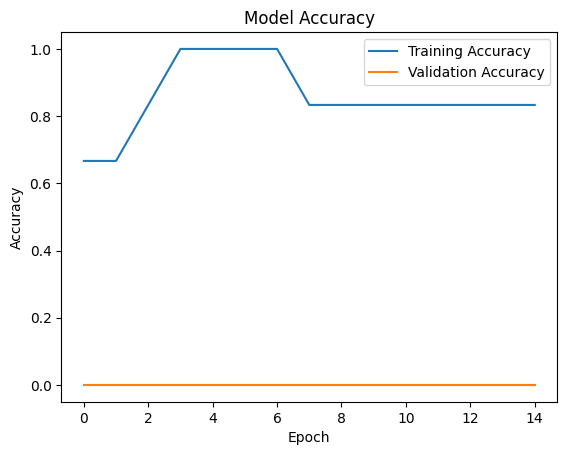

In [10]:
plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

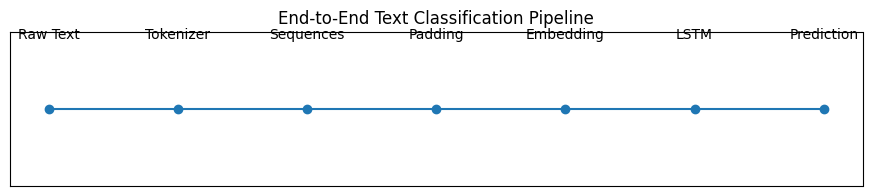

In [11]:
steps = [

    "Raw Text",

    "Tokenizer",

    "Sequences",

    "Padding",

    "Embedding",

    "LSTM",

    "Prediction"

]

plt.figure(figsize=(11,2))

plt.plot(range(len(steps)),
         [1]*len(steps),
         marker="o")

for i, step in enumerate(steps):
    plt.text(i,1.05,step,ha="center")

plt.xticks([])
plt.yticks([])

plt.title("End-to-End Text Classification Pipeline")

plt.show()